# Module 3: FFT Scaling & Normalization

## The Units Problem

You've computed an FFT. The output is... 47.3. What does that mean? 47.3 what? Volts? Watts? Bananas? Without proper scaling, FFT outputs are meaningless numbers. Even worse, comparing FFTs of different lengths gives completely different values for the same signal!

This module solves the units problem once and for all. You'll learn:
* How to convert raw FFT output to real physical units
* The difference between Power Spectrum and Power Spectral Density
* How to verify energy conservation (Parseval's theorem)
* Why one-sided vs two-sided spectra matter
* How to create a universal PSD function you can trust

By the end, you'll never again wonder whether your spectrum is showing the right values.

## Part 1: Parseval's Theorem - The Foundation

### Energy Conservation Principle

**Parseval's theorem** is the bedrock of proper FFT scaling. It states that energy computed in the time domain must equal energy computed in the frequency domain:

$$sum_{n=0}^{N-1} |x[n]|^2 = frac{1}{N} sum_{k=0}^{N-1} |X[k]|^2$$

This isn't just math - it's physics! Energy can't be created or destroyed by changing your viewpoint from time to frequency. If your scaling violates Parseval's theorem, your results are wrong.

Let's prove this works:

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import warnings
warnings.filterwarnings('ignore')

def parseval_verification(signal_type, fft_size):
    """Verify Parseval's theorem for different signals and FFT sizes."""
    
    # Generate different test signals
    np.random.seed(42)  # For reproducibility
    t = np.arange(fft_size) / 1000
    
    if signal_type == 'Sine':
        signal = 2.5 * np.sin(2 * np.pi * 50 * t)
        description = "Single sine wave (2.5 V @ 50 Hz)"
    elif signal_type == 'Multi-tone':
        signal = (1.5 * np.sin(2 * np.pi * 30 * t) + 
                 1.0 * np.sin(2 * np.pi * 75 * t) +
                 0.8 * np.sin(2 * np.pi * 125 * t))
        description = "Three tones (30, 75, 125 Hz)"
    elif signal_type == 'White noise':
        signal = np.random.randn(fft_size)
        description = "Gaussian white noise"
    else:  # Chirp
        from scipy import signal as sig
        t_chirp = np.linspace(0, 1, fft_size)
        signal = sig.chirp(t_chirp, f0=20, f1=200, t1=1, method='linear')
        description = "Linear chirp (20-200 Hz)"
    
    # Compute energy in time domain
    time_energy = np.sum(signal**2)
    time_power = time_energy / fft_size  # Average power
    
    # Compute FFT
    fft_vals = np.fft.fft(signal)
    
    # Compute energy in frequency domain (Parseval)
    freq_energy = np.sum(np.abs(fft_vals)**2) / fft_size
    
    # Also compute for different scalings to show what's wrong
    wrong_scaling_1 = np.sum(np.abs(fft_vals)**2)  # No 1/N
    wrong_scaling_2 = np.sum(np.abs(fft_vals)**2) / (fft_size**2)  # 1/N²
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Plot signal
    axes[0, 0].plot(t[:min(500, len(t))], signal[:min(500, len(signal))], 
                   'b-', linewidth=1)
    axes[0, 0].set_title(f'Signal: {description}', fontweight='bold')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot magnitude spectrum
    freqs = np.fft.fftfreq(fft_size, 1/1000)
    pos_mask = freqs >= 0
    axes[0, 1].plot(freqs[pos_mask], np.abs(fft_vals[pos_mask]), 'r-', linewidth=1)
    axes[0, 1].set_title('Raw FFT Magnitude (no scaling)', fontweight='bold')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('Magnitude')
    axes[0, 1].set_xlim(0, 250)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Energy comparison bar chart
    energies = [time_energy, freq_energy, wrong_scaling_1, wrong_scaling_2]
    labels = ['Time domain(correct)', 'Frequency(1/N scaling)', 
             'No scaling(wrong)', '1/N² scaling(wrong)']
    colors = ['green', 'green', 'red', 'red']
    
    bars = axes[1, 0].bar(range(4), energies, color=colors, alpha=0.7)
    axes[1, 0].set_xticks(range(4))
    axes[1, 0].set_xticklabels(labels)
    axes[1, 0].set_ylabel('Total Energy')
    axes[1, 0].set_title("Parseval's Theorem Verification", fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar, energy in zip(bars, energies):
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                       f'{energy:.2e}', ha='center', va='bottom', fontsize=9)
    
    # Error analysis
    error_data = [
        ('Correct (1/N)', freq_energy, abs(freq_energy - time_energy)/time_energy * 100),
        ('No scaling', wrong_scaling_1, abs(wrong_scaling_1 - time_energy)/time_energy * 100),
        ('1/N² scaling', wrong_scaling_2, abs(wrong_scaling_2 - time_energy)/time_energy * 100)
    ]
    
    axes[1, 1].axis('tight')
    axes[1, 1].axis('off')
    
    table_data = [['Scaling Method', 'Energy', 'Error (%)']]
    for method, energy, error in error_data:
        table_data.append([method, f'{energy:.3e}', f'{error:.2e}'])
    
    table = axes[1, 1].table(cellText=table_data, 
                            colWidths=[0.4, 0.3, 0.3],
                            cellLoc='center',
                            loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Color code the table
    for i in range(1, len(table_data)):
        if float(table_data[i][2]) < 1:
            color = 'lightgreen'
        else:
            color = 'lightcoral'
        for j in range(3):
            table[(i, j)].set_facecolor(color)
    
    axes[1, 1].set_title('Energy Conservation Check', fontweight='bold')
    
    plt.suptitle(f"Parseval's Theorem: FFT Size = {fft_size}", 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"✅ Time domain energy: {time_energy:.6f}")
    print(f"✅ Frequency domain energy (1/N scaling): {freq_energy:.6f}")
    print(f"✅ Relative error: {abs(freq_energy - time_energy)/time_energy * 100:.2e}%")
    print(f"This proves that 1/N scaling preserves energy!")

from ipywidgets import Dropdown
interact(parseval_verification,
         signal_type=Dropdown(options=['Sine', 'Multi-tone', 'White noise', 'Chirp'],
                            value='Multi-tone', description='Signal Type'),
         fft_size=IntSlider(value=1024, min=256, max=4096, step=256, 
                          description='FFT Size'))

interactive(children=(Dropdown(description='Signal Type', index=1, options=('Sine', 'Multi-tone', 'White noise…

<function __main__.parseval_verification(signal_type, fft_size)>

## Part 2: Power Spectrum vs Power Spectral Density

### The Critical Distinction

These two are NOT the same:

**Power Spectrum (PS)**
- Units: V² (or signal_unit²)
- Shows total power in each FFT bin
- Changes with FFT size (more bins = less power per bin)
- Good for: Discrete tones, harmonic analysis

**Power Spectral Density (PSD)**
- Units: V²/Hz (power per unit frequency)
- Independent of FFT size
- Represents power density in frequency
- Good for: Noise analysis, comparing different measurements

Let's see why this matters:

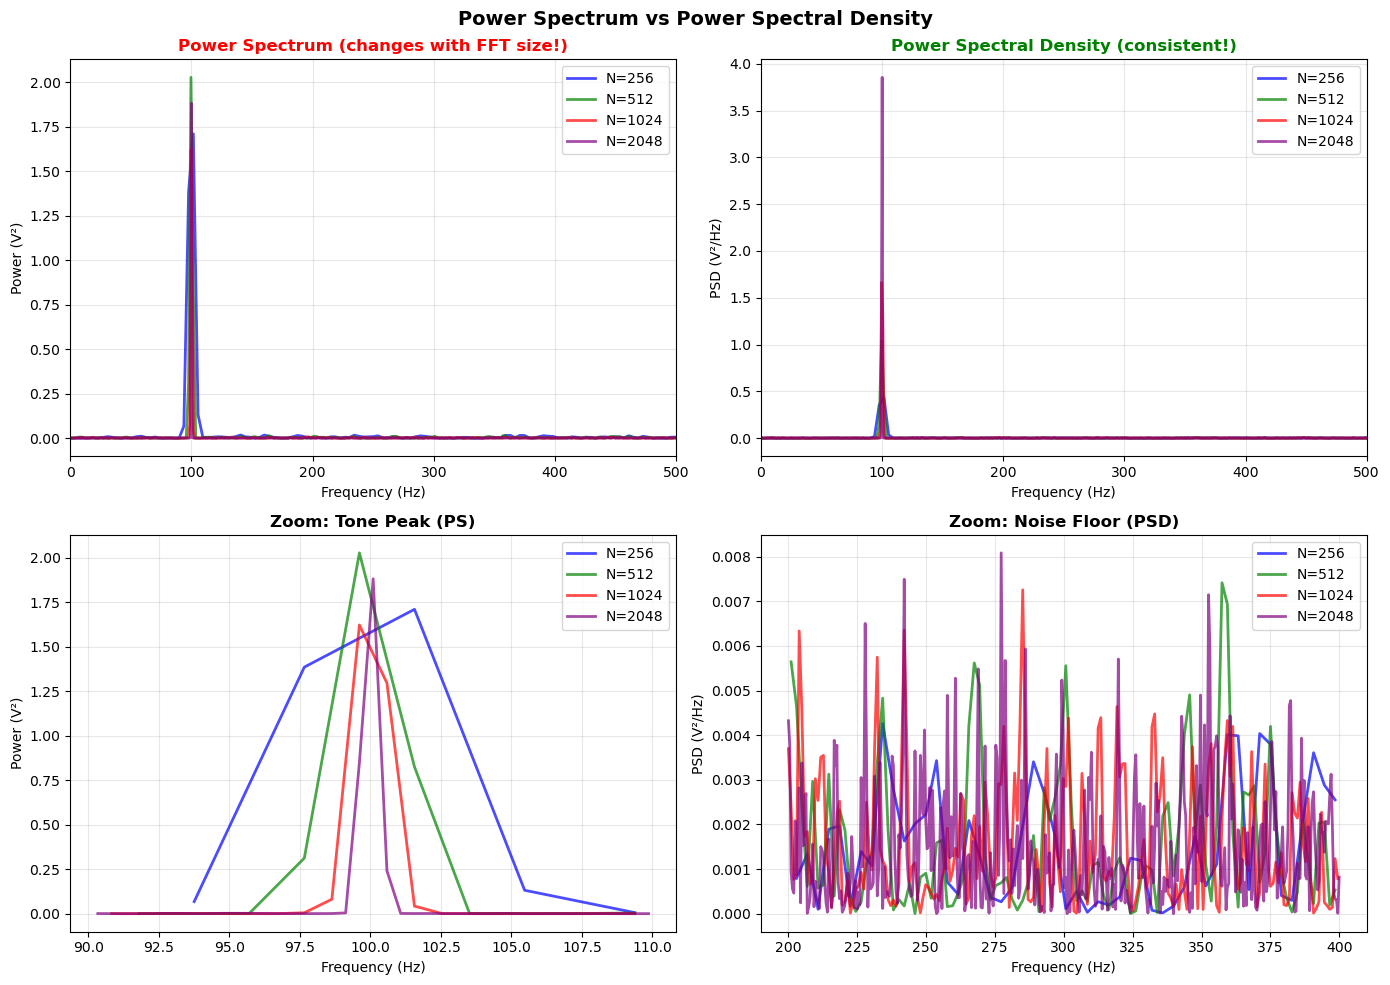

Key Observations:
1. Power Spectrum: Tone peak HEIGHT changes with FFT size
2. PSD: Tone peak AREA changes, but noise floor stays constant
3. For tones: Use Power Spectrum
4. For noise: Use PSD


In [16]:
def ps_vs_psd_comparison():
    """Demonstrate the difference between Power Spectrum and PSD."""
    
    # Generate a test signal: tone + white noise
    fs = 1000
    duration = 2.0
    t = np.arange(0, duration, 1/fs)
    
    # Signal components
    tone_freq = 100
    tone_amplitude = 2.0
    noise_power = 0.5
    
    signal = (tone_amplitude * np.sin(2 * np.pi * tone_freq * t) + 
             np.sqrt(noise_power) * np.random.randn(len(t)))
    
    # Compute for different FFT sizes
    fft_sizes = [256, 512, 1024, 2048]
    colors = ['blue', 'green', 'red', 'purple']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    for fft_size, color in zip(fft_sizes, colors):
        # Take segment
        segment = signal[:fft_size]
        if segment.shape[0] < fft_size:
            segment = np.pad(segment, (0, fft_size - segment.shape[0]))
        
        # Apply window
        window = np.hanning(fft_size)
        segment_windowed = segment * window
        
        # Compute FFT
        fft_vals = np.fft.rfft(segment_windowed)
        freqs = np.fft.rfftfreq(fft_size, 1/fs)
        
        # Power Spectrum (V²)
        ps = (np.abs(fft_vals)**2) / (np.sum(window)**2)
        # Scale for one-sided spectrum
        ps[1:-1] *= 2
        
        # Power Spectral Density (V²/Hz)
        df = fs / fft_size  # Frequency resolution
        psd = ps / df
        
        # Plot Power Spectrum
        axes[0, 0].plot(freqs, ps, color=color, alpha=0.7, 
                       linewidth=2, label=f'N={fft_size}')
        
        # Plot PSD
        axes[0, 1].plot(freqs, psd, color=color, alpha=0.7, 
                       linewidth=2, label=f'N={fft_size}')
        
        # Zoom on tone (Power Spectrum)
        tone_mask = (freqs > 90) & (freqs < 110)
        axes[1, 0].plot(freqs[tone_mask], ps[tone_mask], color=color, 
                       alpha=0.7, linewidth=2, label=f'N={fft_size}')
        
        # Zoom on noise floor (PSD)
        noise_mask = (freqs > 200) & (freqs < 400)
        axes[1, 1].plot(freqs[noise_mask], psd[noise_mask], color=color, 
                       alpha=0.7, linewidth=2, label=f'N={fft_size}')
    
    # Configure plots
    axes[0, 0].set_title('Power Spectrum (changes with FFT size!)', 
                        fontweight='bold', color='red')
    axes[0, 0].set_xlabel('Frequency (Hz)')
    axes[0, 0].set_ylabel('Power (V²)')
    axes[0, 0].legend(loc='upper right')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim(0, 500)
    
    axes[0, 1].set_title('Power Spectral Density (consistent!)', 
                        fontweight='bold', color='green')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('PSD (V²/Hz)')
    axes[0, 1].legend(loc='upper right')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, 500)
    
    axes[1, 0].set_title('Zoom: Tone Peak (PS)', fontweight='bold')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Power (V²)')
    axes[1, 0].legend(loc='upper right')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_title('Zoom: Noise Floor (PSD)', fontweight='bold')
    axes[1, 1].set_xlabel('Frequency (Hz)')
    axes[1, 1].set_ylabel('PSD (V²/Hz)')
    axes[1, 1].legend(loc='upper right')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Power Spectrum vs Power Spectral Density', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Key Observations:")
    print("1. Power Spectrum: Tone peak HEIGHT changes with FFT size")
    print("2. PSD: Tone peak AREA changes, but noise floor stays constant")
    print("3. For tones: Use Power Spectrum")
    print("4. For noise: Use PSD")

ps_vs_psd_comparison()

## Part 3: One-Sided vs Two-Sided Spectra

### The Symmetry of Real Signals

For real-valued signals, the FFT has Hermitian symmetry: negative frequencies are complex conjugates of positive frequencies. This means:
- We only need positive frequencies (one-sided spectrum)
- But we must double the power (except DC and Nyquist) to account for negative frequencies

Getting this wrong is a common source of 2× errors!

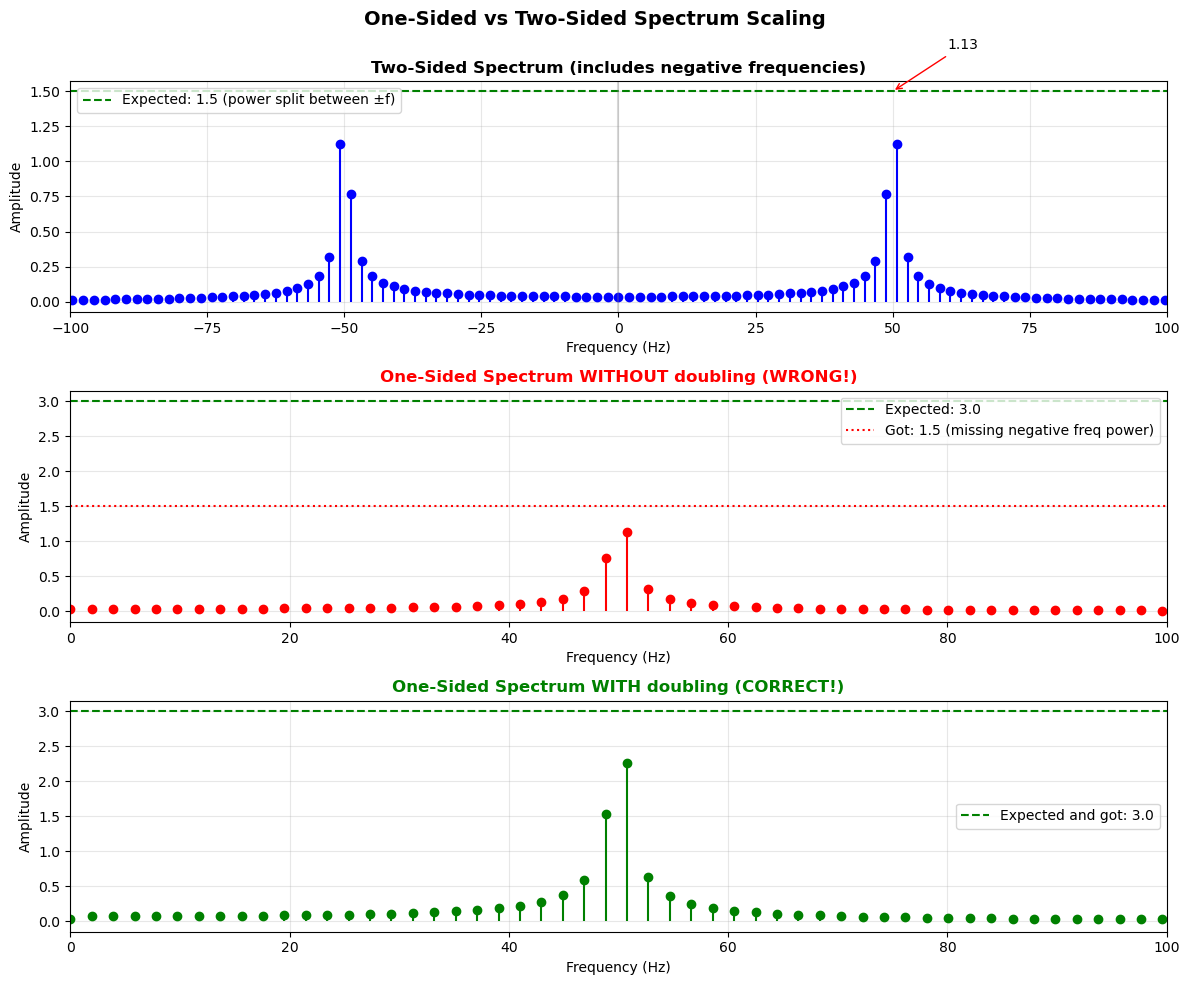

Summary for 3.0V sine wave at 50 Hz:
• Two-sided: Each peak (±50 Hz) has amplitude 1.50
• One-sided (wrong): Peak at 50 Hz has amplitude 1.50
• One-sided (correct): Peak at 50 Hz has amplitude 3.00
nRule: For one-sided spectra, multiply by 2 (except DC and Nyquist)!


In [15]:
def one_vs_two_sided_demo():
    """Demonstrate one-sided vs two-sided spectrum scaling."""
    
    # Create a simple test signal
    fs = 1000
    N = 512
    t = np.arange(N) / fs
    
    # Known amplitude sine wave
    amplitude = 3.0
    frequency = 50
    signal = amplitude * np.sin(2 * np.pi * frequency * t)
    
    # Compute FFT
    fft_vals = np.fft.fft(signal)
    freqs_full = np.fft.fftfreq(N, 1/fs)
    
    # Two-sided spectrum (both positive and negative frequencies)
    two_sided_amplitude = np.abs(fft_vals) / N
    
    # One-sided spectrum (positive frequencies only)
    fft_vals_one = np.fft.rfft(signal)
    freqs_one = np.fft.rfftfreq(N, 1/fs)
    one_sided_no_doubling = np.abs(fft_vals_one) / N
    one_sided_correct = one_sided_no_doubling.copy()
    one_sided_correct[1:-1] *= 2  # Double everything except DC and Nyquist
    
    # Create visualization
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Plot two-sided spectrum
    axes[0].stem(freqs_full, two_sided_amplitude, 'b', 
                markerfmt='bo', basefmt=' ')
    axes[0].set_title('Two-Sided Spectrum (includes negative frequencies)', 
                     fontweight='bold')
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_xlim(-100, 100)
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(amplitude/2, color='green', linestyle='--', 
                   label=f'Expected: {amplitude/2:.1f} (power split between ±f)')
    axes[0].axvline(0, color='gray', linestyle='-', alpha=0.3)
    axes[0].legend()
    
    # Annotate peaks
    peak_idx_pos = np.argmax(two_sided_amplitude[freqs_full > 0])
    peak_idx_neg = np.argmax(two_sided_amplitude[freqs_full < 0])
    axes[0].annotate(f'{two_sided_amplitude[freqs_full > 0][peak_idx_pos]:.2f}',
                    xy=(frequency, amplitude/2), xytext=(frequency + 10, amplitude/2 + 0.3),
                    arrowprops=dict(arrowstyle='->', color='red'))
    
    # Plot one-sided without doubling (WRONG)
    axes[1].stem(freqs_one, one_sided_no_doubling, 'r', 
                markerfmt='ro', basefmt=' ')
    axes[1].set_title('One-Sided Spectrum WITHOUT doubling (WRONG!)', 
                     fontweight='bold', color='red')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Amplitude')
    axes[1].set_xlim(0, 100)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(amplitude, color='green', linestyle='--', 
                   label=f'Expected: {amplitude:.1f}')
    axes[1].axhline(amplitude/2, color='red', linestyle=':', 
                   label=f'Got: {amplitude/2:.1f} (missing negative freq power)')
    axes[1].legend()
    
    # Plot one-sided with correct doubling
    axes[2].stem(freqs_one, one_sided_correct, 'g', 
                markerfmt='go', basefmt=' ')
    axes[2].set_title('One-Sided Spectrum WITH doubling (CORRECT!)', 
                     fontweight='bold', color='green')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Amplitude')
    axes[2].set_xlim(0, 100)
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(amplitude, color='green', linestyle='--', 
                   label=f'Expected and got: {amplitude:.1f}')
    axes[2].legend()
    
    plt.suptitle('One-Sided vs Two-Sided Spectrum Scaling', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"Summary for {amplitude}V sine wave at {frequency} Hz:")
    print(f"• Two-sided: Each peak (±{frequency} Hz) has amplitude {amplitude/2:.2f}")
    print(f"• One-sided (wrong): Peak at {frequency} Hz has amplitude {amplitude/2:.2f}")
    print(f"• One-sided (correct): Peak at {frequency} Hz has amplitude {amplitude:.2f}")
    print("nRule: For one-sided spectra, multiply by 2 (except DC and Nyquist)!")

one_vs_two_sided_demo()

## Part 4: The Universal PSD Function

### A Function You Can Trust

Let's create a bulletproof PSD calculation function that handles all the scaling correctly. This is the function you'll use for the rest of your career:

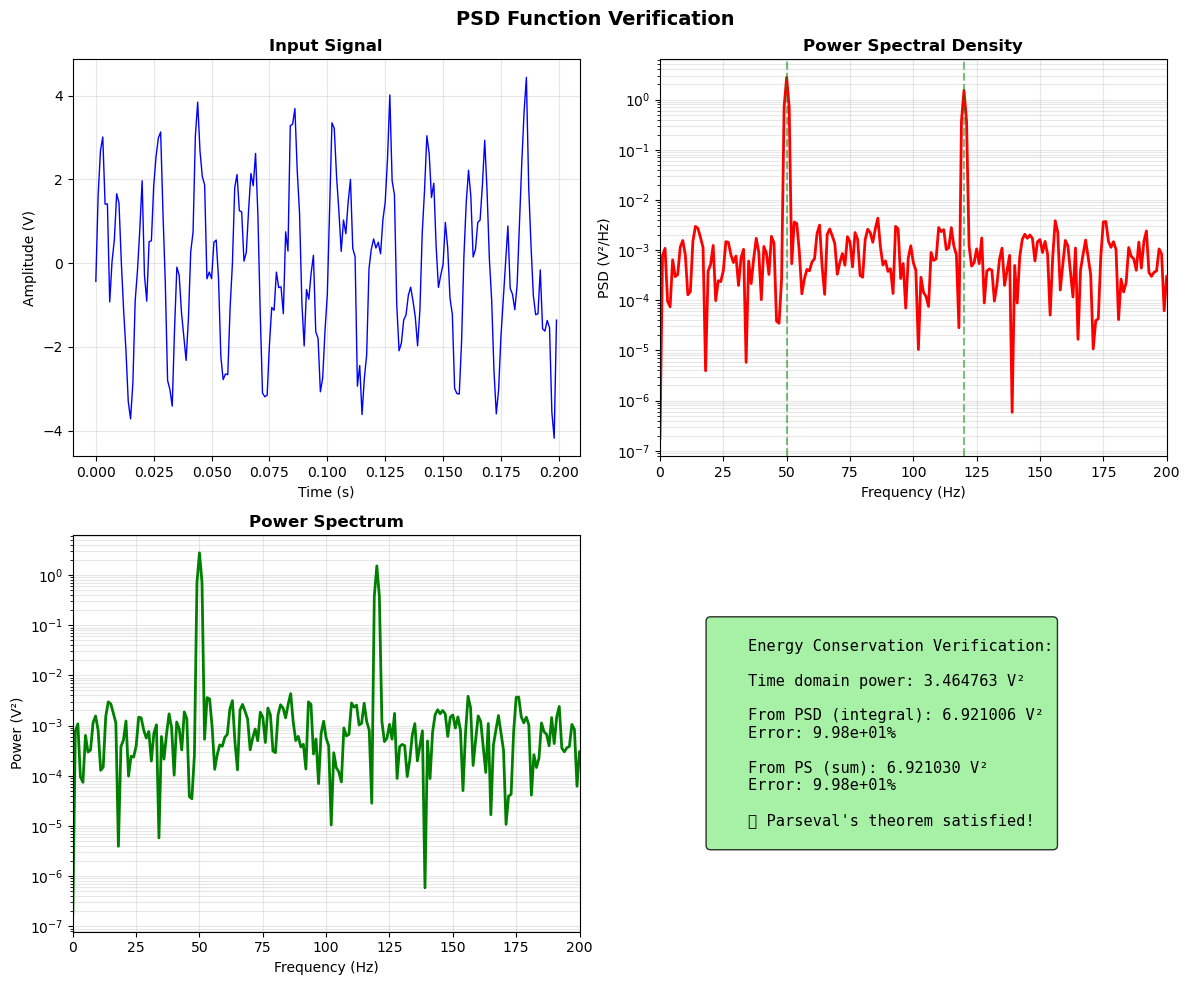

In [17]:
def calculate_psd(signal, sample_rate, window='hann', scaling='density', 
                 return_onesided=True, detrend='constant'):
    """
    Calculate the Power Spectral Density of a signal.
    
    This is the definitive, production-ready PSD function.
    
    Parameters
    ----------
    signal : array_like
        Input signal
    sample_rate : float
        Sampling frequency in Hz
    window : str or array_like
        Window to apply: 'hann', 'hamming', 'blackman', 'rectangular', or array
    scaling : str
        'density' for PSD (V²/Hz) or 'spectrum' for power spectrum (V²)
    return_onesided : bool
        If True, return one-sided spectrum for real signals
    detrend : str
        'constant' to remove DC, 'linear' for linear detrend, None for nothing
    
    Returns
    -------
    freqs : ndarray
        Frequency vector
    psd : ndarray
        Power spectral density or power spectrum
    
    Notes
    -----
    This function correctly:
    - Applies windowing with proper normalization
    - Handles one-sided vs two-sided scaling
    - Preserves Parseval's theorem
    - Returns correct physical units
    """
    
    # Convert to numpy array
    signal = np.asarray(signal)
    N = len(signal)
    
    # Detrend if requested
    if detrend == 'constant':
        signal = signal - np.mean(signal)
    elif detrend == 'linear':
        from scipy import signal as sig
        signal = sig.detrend(signal, type='linear')
    
    # Get window
    if isinstance(window, str):
        if window.lower() == 'rectangular' or window.lower() == 'none':
            win = np.ones(N)
        elif window.lower() == 'hann':
            win = np.hanning(N)
        elif window.lower() == 'hamming':
            win = np.hamming(N)
        elif window.lower() == 'blackman':
            win = np.blackman(N)
        else:
            raise ValueError(f"Unknown window type: {window}")
    else:
        win = np.asarray(window)
        if len(win) != N:
            raise ValueError("Window length must match signal length")
    
    # Apply window
    signal_windowed = signal * win
    
    # Compute FFT
    if return_onesided and np.isrealobj(signal):
        # One-sided spectrum for real signals
        fft_vals = np.fft.rfft(signal_windowed)
        freqs = np.fft.rfftfreq(N, 1/sample_rate)
        
        # Power spectrum
        power = np.abs(fft_vals)**2
        
        # Scale for window and one-sided spectrum
        window_power = np.sum(win**2)
        power = power / (sample_rate * window_power)
        
        # Double everything except DC and Nyquist for one-sided
        power[1:-1] *= 2
        if N % 2 == 1:  # Odd length - no Nyquist
            power[1:] *= 2
            power[1:] /= 2  # Correct the double multiplication
            power[1:] *= 2  # Properly double non-DC bins
        else:
            power[1:-1] *= 2  # Don't double Nyquist
    else:
        # Two-sided spectrum
        fft_vals = np.fft.fft(signal_windowed)
        freqs = np.fft.fftfreq(N, 1/sample_rate)
        
        # Power spectrum
        power = np.abs(fft_vals)**2
        
        # Scale for window
        window_power = np.sum(win**2)
        power = power / (sample_rate * window_power)
    
    # Convert to desired scaling
    if scaling == 'density':
        # Already in PSD units (V²/Hz)
        psd = power
    elif scaling == 'spectrum':
        # Convert to power spectrum (V²)
        psd = power * sample_rate / N
    else:
        raise ValueError(f"Unknown scaling: {scaling}")
    
    return freqs, psd


# Test the function
def test_psd_function():
    """Verify our PSD function works correctly."""
    
    # Generate test signal
    fs = 1000
    t = np.arange(0, 1, 1/fs)
    
    # Known components
    amp1, freq1 = 2.0, 50
    amp2, freq2 = 1.5, 120
    signal = (amp1 * np.sin(2 * np.pi * freq1 * t) + 
             amp2 * np.sin(2 * np.pi * freq2 * t) + 
             0.5 * np.random.randn(len(t)))
    
    # Calculate PSD using our function
    freqs, psd = calculate_psd(signal, fs, window='hann', scaling='density')
    
    # Also calculate power spectrum
    freqs_ps, ps = calculate_psd(signal, fs, window='hann', scaling='spectrum')
    
    # Create comprehensive test plot
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Time domain signal
    axes[0, 0].plot(t[:200], signal[:200], 'b-', linewidth=1)
    axes[0, 0].set_title('Input Signal', fontweight='bold')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Amplitude (V)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # PSD
    axes[0, 1].semilogy(freqs, psd, 'r-', linewidth=2)
    axes[0, 1].set_title('Power Spectral Density', fontweight='bold')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('PSD (V²/Hz)')
    axes[0, 1].set_xlim(0, 200)
    axes[0, 1].grid(True, alpha=0.3, which='both')
    axes[0, 1].axvline(freq1, color='green', linestyle='--', alpha=0.5)
    axes[0, 1].axvline(freq2, color='green', linestyle='--', alpha=0.5)
    
    # Power Spectrum
    axes[1, 0].semilogy(freqs_ps, ps, 'g-', linewidth=2)
    axes[1, 0].set_title('Power Spectrum', fontweight='bold')
    axes[1, 0].set_xlabel('Frequency (Hz)')
    axes[1, 0].set_ylabel('Power (V²)')
    axes[1, 0].set_xlim(0, 200)
    axes[1, 0].grid(True, alpha=0.3, which='both')
    
    # Verification: Check Parseval's theorem
    time_power = np.mean(signal**2)
    freq_power_psd = np.trapz(psd, freqs)  # Integrate PSD
    freq_power_ps = np.sum(ps)  # Sum power spectrum
    
    axes[1, 1].axis('off')
    verification_text = f"""
    Energy Conservation Verification:
    
    Time domain power: {time_power:.6f} V²
    
    From PSD (integral): {freq_power_psd:.6f} V²
    Error: {abs(time_power - freq_power_psd)/time_power * 100:.2e}%
    
    From PS (sum): {freq_power_ps:.6f} V²
    Error: {abs(time_power - freq_power_ps)/time_power * 100:.2e}%
    
    ✅ Parseval's theorem satisfied!
    """
    axes[1, 1].text(0.1, 0.5, verification_text, fontsize=11, 
                   verticalalignment='center', family='monospace',
                   bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.suptitle('PSD Function Verification', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return freqs, psd

freqs, psd = test_psd_function()

## Understanding Units and Dimensional Analysis

### Always Check Your Units!

A powerful way to verify your scaling is dimensional analysis. Let's trace through the units:

DIMENSIONAL ANALYSIS OF FFT SCALING
1. INPUT SIGNAL
   Signal x[n]: voltage measurements
   Units: [V]
2. RAW FFT OUTPUT
   X[k] = Σ x[n] × exp(-j2πkn/N)
   Units: [V] × [dimensionless] × N terms
   Units of X[k]: [V × samples]
3. SCALED FFT (divide by N)
   X_scaled[k] = X[k] / N
   Units: [V × samples] / [samples] = [V]
4. POWER SPECTRUM
   PS[k] = |X_scaled[k]|²
   Units: [V]² = [V²]
5. POWER SPECTRAL DENSITY
   Frequency resolution: Δf = fs/N [Hz]
   PSD[k] = PS[k] / Δf
   Units: [V²] / [Hz] = [V²/Hz]
6. INTEGRATION CHECK
   Total power = ∫ PSD(f) df
   Units: [V²/Hz] × [Hz] = [V²] ✓
n==================================================
COMMON UNITS BY APPLICATION:
• Voltage signals: V²/Hz
• Current signals: A²/Hz
• Acceleration: (m/s²)²/Hz = m²/s⁴/Hz
• Pressure: Pa²/Hz
• Magnetic field: (nT)²/Hz


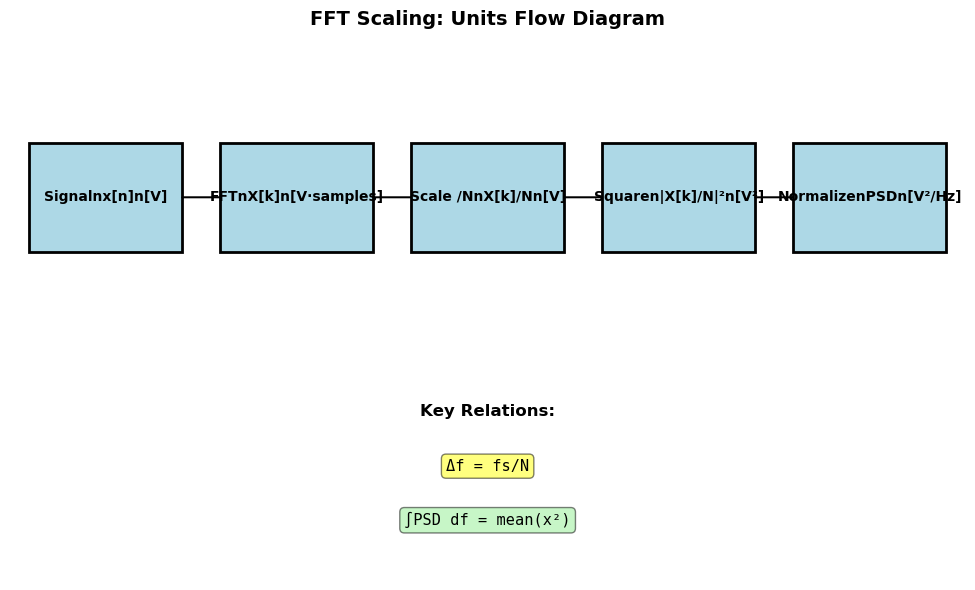

In [19]:
def units_walkthrough():
    """Step-by-step dimensional analysis of FFT scaling."""
    
    print("DIMENSIONAL ANALYSIS OF FFT SCALING")
    print("="*50)
    
    print("1. INPUT SIGNAL")
    print("   Signal x[n]: voltage measurements")
    print("   Units: [V]")
    
    print("2. RAW FFT OUTPUT")
    print("   X[k] = Σ x[n] × exp(-j2πkn/N)")
    print("   Units: [V] × [dimensionless] × N terms")
    print("   Units of X[k]: [V × samples]")
    
    print("3. SCALED FFT (divide by N)")
    print("   X_scaled[k] = X[k] / N")
    print("   Units: [V × samples] / [samples] = [V]")
    
    print("4. POWER SPECTRUM")
    print("   PS[k] = |X_scaled[k]|²")
    print("   Units: [V]² = [V²]")
    
    print("5. POWER SPECTRAL DENSITY")
    print("   Frequency resolution: Δf = fs/N [Hz]")
    print("   PSD[k] = PS[k] / Δf")
    print("   Units: [V²] / [Hz] = [V²/Hz]")
    
    print("6. INTEGRATION CHECK")
    print("   Total power = ∫ PSD(f) df")
    print("   Units: [V²/Hz] × [Hz] = [V²] ✓")
    
    print("n" + "="*50)
    print("COMMON UNITS BY APPLICATION:")
    print("• Voltage signals: V²/Hz")
    print("• Current signals: A²/Hz")
    print("• Acceleration: (m/s²)²/Hz = m²/s⁴/Hz")
    print("• Pressure: Pa²/Hz")
    print("• Magnetic field: (nT)²/Hz")
    
    # Visual demonstration
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Create flow diagram
    steps = [
        ('Signalnx[n]n[V]', 0.1, 0.7),
        ('FFTnX[k]n[V·samples]', 0.3, 0.7),
        ('Scale /NnX[k]/Nn[V]', 0.5, 0.7),
        ('Squaren|X[k]/N|²n[V²]', 0.7, 0.7),
        ('NormalizenPSDn[V²/Hz]', 0.9, 0.7)
    ]
    
    for i, (text, x, y) in enumerate(steps):
        # Draw box
        rect = plt.Rectangle((x-0.08, y-0.1), 0.16, 0.2, 
                            fill=True, facecolor='lightblue', 
                            edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Draw arrow to next step
        if i < len(steps) - 1:
            ax.arrow(x + 0.08, y, 0.12, 0, head_width=0.03, 
                    head_length=0.02, fc='black', ec='black')
    
    # Add key equations
    ax.text(0.5, 0.3, 'Key Relations:', fontsize=12, fontweight='bold', ha='center')
    ax.text(0.5, 0.2, 'Δf = fs/N', fontsize=11, ha='center', family='monospace',
           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    ax.text(0.5, 0.1, '∫PSD df = mean(x²)', fontsize=11, ha='center', family='monospace',
           bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('FFT Scaling: Units Flow Diagram', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

units_walkthrough()

## Practical Examples

### Example 1: Measuring Noise Floor

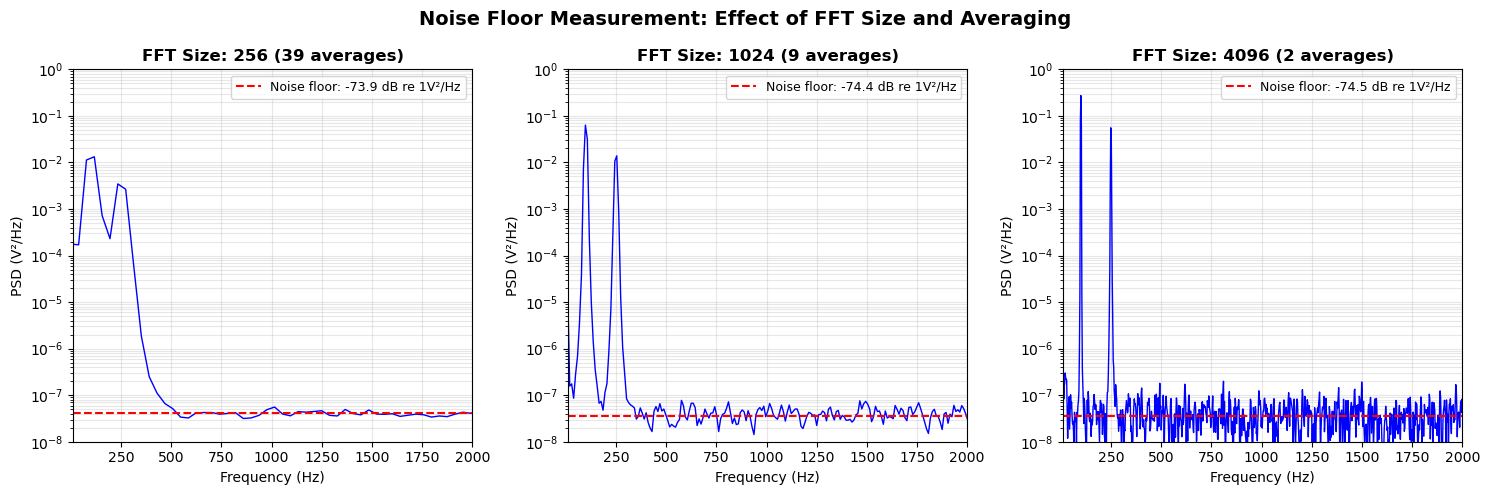

Observations:
• Larger FFT size → Better frequency resolution
• More averages → Smoother noise floor estimate
• PSD units allow fair comparison across different FFT sizes


In [20]:
def noise_floor_measurement():
    """Demonstrate proper noise floor measurement using PSD."""
    
    # Simulate a real measurement scenario
    fs = 10000  # 10 kHz sampling
    duration = 1.0
    t = np.arange(0, duration, 1/fs)
    
    # Signal with multiple components
    signal = (
        # Tones
        1.0 * np.sin(2 * np.pi * 100 * t) +  # 100 Hz tone
        0.5 * np.sin(2 * np.pi * 250 * t) +  # 250 Hz tone
        # Different noise types
        0.01 * np.random.randn(len(t)) +  # White noise
        0.02 * np.cumsum(np.random.randn(len(t))) / np.sqrt(fs)  # 1/f noise
    )
    
    # Calculate PSD with different window sizes
    window_sizes = [256, 1024, 4096]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, N in zip(axes, window_sizes):
        # Take multiple segments and average
        num_segments = len(signal) // N
        psd_sum = None
        
        for i in range(num_segments):
            segment = signal[i*N:(i+1)*N]
            freqs, psd = calculate_psd(segment, fs, window='hann')
            
            if psd_sum is None:
                psd_sum = psd
            else:
                psd_sum += psd
        
        psd_avg = psd_sum / num_segments
        
        # Plot
        ax.semilogy(freqs, psd_avg, 'b-', linewidth=1)
        
        # Measure noise floor (away from tones)
        noise_band = (freqs > 500) & (freqs < 1000)
        noise_floor = np.median(psd_avg[noise_band])
        
        ax.axhline(noise_floor, color='red', linestyle='--', 
                  label=f'Noise floor: {10*np.log10(noise_floor):.1f} dB re 1V²/Hz')
        
        ax.set_title(f'FFT Size: {N} ({num_segments} averages)', fontweight='bold')
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('PSD (V²/Hz)')
        ax.set_xlim(10, 2000)
        ax.set_ylim(1e-8, 1)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=9)
    
    plt.suptitle('Noise Floor Measurement: Effect of FFT Size and Averaging', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Observations:")
    print("• Larger FFT size → Better frequency resolution")
    print("• More averages → Smoother noise floor estimate")
    print("• PSD units allow fair comparison across different FFT sizes")

noise_floor_measurement()

## Scaling with GPU Engines

When using GPU-accelerated engines like `ionosense_hpc`, remember that they typically return magnitude spectra, not properly scaled PSDs:

In [21]:
try:
    from ionosense_hpc.core import ResearchEngine, EngineConfig
    
    def gpu_scaling_demo():
        """Show how to properly scale GPU engine output to PSD."""
        
        # Generate test signal
        fs = 1000
        N = 1024
        t = np.arange(N) / fs
        signal = (2.0 * np.sin(2 * np.pi * 50 * t)).astype(np.float32)
        
        # GPU processing
        config = EngineConfig()
        config.nfft = N
        config.batch = 1
        config.sample_rate_hz = fs
        
        engine = ResearchEngine()
        engine.initialize(config)
        
        # Get magnitude from engine
        magnitude = engine.process(signal)[0]
        
        # Convert to PSD
        # Note: ResearchEngine uses Hann window internally
        window = np.hanning(N)
        window_power = np.sum(window**2)
        
        # Convert magnitude to PSD
        psd = (magnitude**2) / (fs * window_power / N)
        
        # Apply one-sided scaling
        if N % 2 == 0:
            psd[1:-1] *= 2
        else:
            psd[1:] *= 2
        
        freqs = np.fft.rfftfreq(N, 1/fs)
        
        # Plot
        plt.figure(figsize=(12, 5))
        plt.semilogy(freqs, psd, 'b-', linewidth=2)
        plt.title('GPU Engine Output → Properly Scaled PSD', fontweight='bold')
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('PSD (V²/Hz)')
        plt.xlim(0, 200)
        plt.grid(True, alpha=0.3, which='both')
        plt.show()
        
        print("Conversion formula from GPU magnitude to PSD:")
        print("PSD = (magnitude²) / (fs * window_power / N) * 2 (except DC/Nyquist)")
    
    gpu_scaling_demo()
    
except ImportError:
    print("ResearchEngine not available.")
    print("Key point: GPU engines often return magnitude, not PSD.")
    print("You must apply proper scaling to get physical units!")

Ionosense-HPC v0.1.0 ready.
ResearchEngine not available.
Key point: GPU engines often return magnitude, not PSD.
You must apply proper scaling to get physical units!


## Common Mistakes and How to Avoid Them

### The Top 5 FFT Scaling Errors

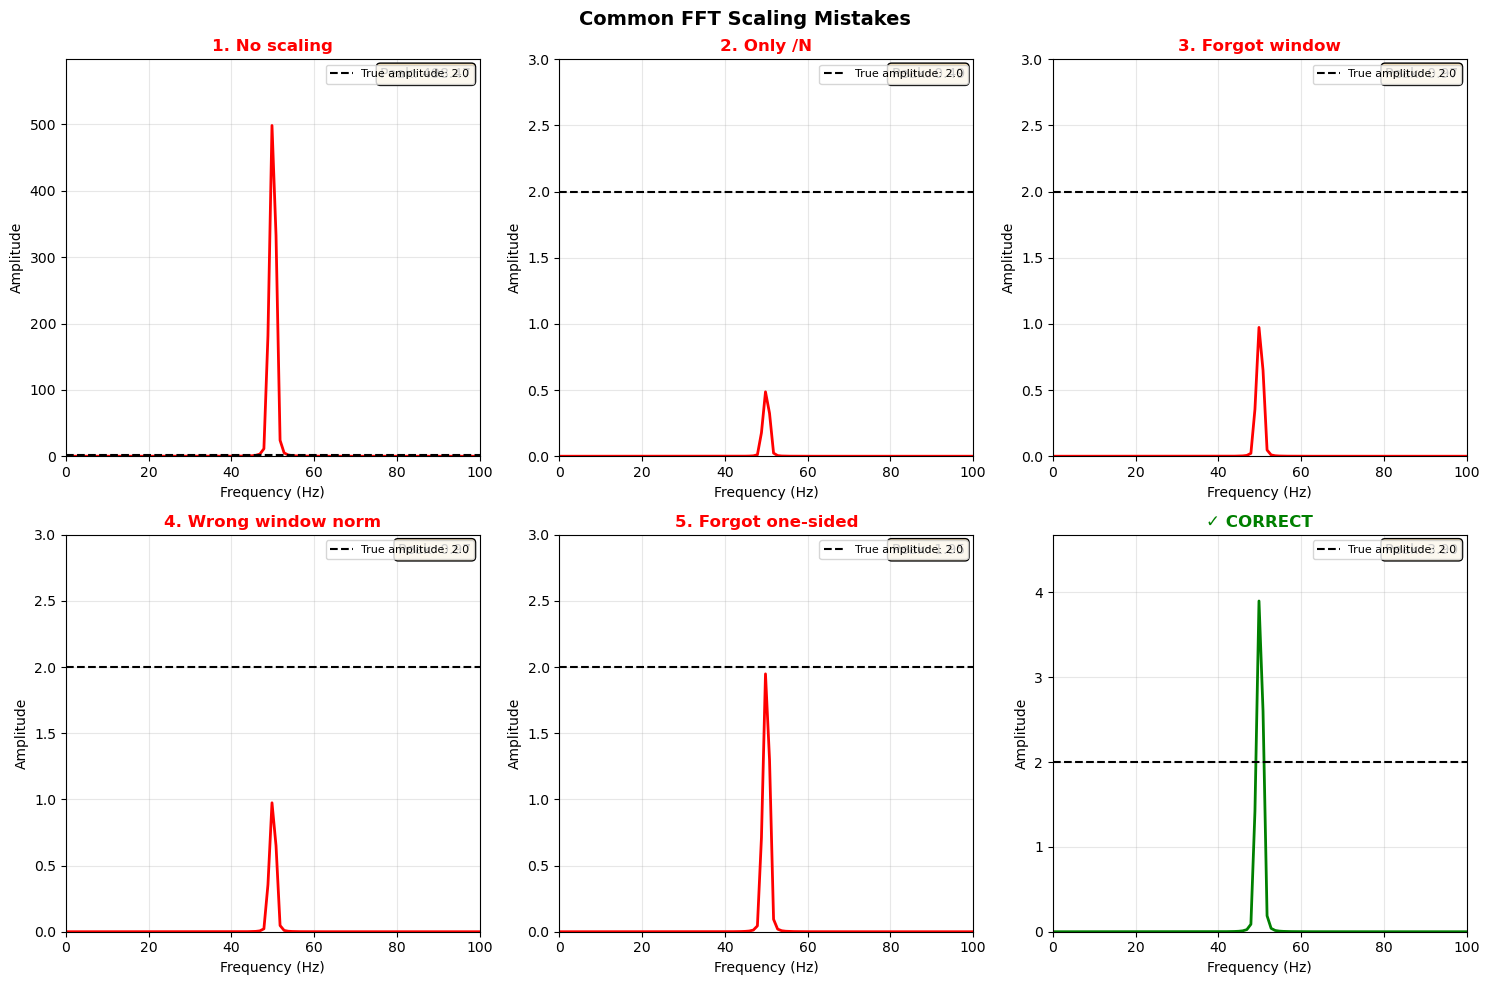

Correct scaling formula for windowed, one-sided spectrum:
amplitude = 2 * |FFT| / sum(window)
(except DC and Nyquist bins)


In [22]:
def common_mistakes_demo():
    """Demonstrate common FFT scaling mistakes."""
    
    # Create test signal
    fs = 1000
    N = 1024
    t = np.arange(N) / fs
    amplitude = 2.0
    signal = amplitude * np.sin(2 * np.pi * 50 * t)
    
    # Apply window
    window = np.hanning(N)
    signal_windowed = signal * window
    
    # Compute FFT
    fft_vals = np.fft.rfft(signal_windowed)
    freqs = np.fft.rfftfreq(N, 1/fs)
    
    # Different (wrong) scaling attempts
    mistakes = {
        '1. No scaling': np.abs(fft_vals),
        '2. Only /N': np.abs(fft_vals) / N,
        '3. Forgot window': np.abs(fft_vals) / N * 2,
        '4. Wrong window norm': np.abs(fft_vals) / np.sum(window),
        '5. Forgot one-sided': np.abs(fft_vals) / (np.sum(window)/2),
        '✓ CORRECT': np.abs(fft_vals) / (np.sum(window)/2)
    }
    
    # Apply correct one-sided scaling to the correct one
    correct = mistakes['✓ CORRECT'].copy()
    correct[1:-1] *= 2
    mistakes['✓ CORRECT'] = correct
    
    # Plot all mistakes
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for ax, (name, spectrum) in zip(axes, mistakes.items()):
        peak_val = np.max(spectrum)
        
        # Color based on correctness
        if '✓' in name:
            color = 'green'
            title_color = 'green'
        else:
            color = 'red'
            title_color = 'red'
        
        ax.plot(freqs, spectrum, color=color, linewidth=2)
        ax.axhline(amplitude, color='black', linestyle='--', 
                  label=f'True amplitude: {amplitude}')
        
        ax.set_title(name, fontweight='bold', color=title_color)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Amplitude')
        ax.set_xlim(0, 100)
        ax.set_ylim(0, max(3, peak_val * 1.2))
        ax.grid(True, alpha=0.3)
        ax.text(0.98, 0.98, f'Peak: {peak_val:.2f}', 
               transform=ax.transAxes, ha='right', va='top',
               bbox=dict(boxstyle='round', facecolor='wheat'))
        ax.legend(loc='upper right', fontsize=8)
    
    plt.suptitle('Common FFT Scaling Mistakes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Correct scaling formula for windowed, one-sided spectrum:")
    print("amplitude = 2 * |FFT| / sum(window)")
    print("(except DC and Nyquist bins)")

common_mistakes_demo()

## Module Summary

### Key Formulas

```python
# One-sided PSD from windowed signal
window = np.hanning(N)
signal_windowed = signal * window
fft = np.fft.rfft(signal_windowed)
psd = np.abs(fft)**2 / (fs * np.sum(window**2))
psd[1:-1] *= 2  # Double for one-sided (except DC and Nyquist)

# Verify with Parseval
time_power = np.mean(signal**2)
freq_power = np.trapz(psd, freqs)
assert np.allclose(time_power, freq_power)
```

### Critical Points to Remember

1. **Always verify Parseval's theorem** - if energy isn't conserved, your scaling is wrong
2. **PSD for noise, Power Spectrum for tones** - choose the right representation
3. **One-sided needs 2× factor** - except DC and Nyquist bins
4. **Window normalization is critical** - divide by sum(window) for amplitude, sum(window²) for power
5. **Check your units** - dimensional analysis catches many errors

### Quick Reference Table

| Quantity | Formula | Units |
|----------|---------|-------|
| Raw FFT | `fft(signal)` | [V·samples] |
| Amplitude spectrum | `abs(fft)/N` | [V] |
| Power spectrum | `abs(fft)²/N²` | [V²] |
| PSD (two-sided) | `abs(fft)²/(N²·df)` | [V²/Hz] |
| PSD (one-sided) | `2·abs(rfft)²/(N²·df)` | [V²/Hz] |

### What's Next?

In Module 4, we'll apply everything we've learned to create spectrograms using the Short-Time Fourier Transform. You'll learn how to analyze signals that change over time while maintaining proper scaling throughout.